# Cat Detection — Training YOLO26 on Your YOLO Dataset

In [1]:
!pip install opencv-python


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install ultralytics torch torchvision matplotlib pandas pillow opencv-python pyyaml


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import random
from pathlib import Path
from collections import Counter

import cv2
import yaml
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

from ultralytics import YOLO

In [4]:
import os
import hashlib
from pathlib import Path

# Paths
image_dir = Path(r"C://Users//Asus//Downloads//dataset//images")
label_dir = Path(r"C://Users//Asus//Downloads//dataset//labels")

print("Starting dataset cleaning...")

# -----------------------------
# 1. REMOVE DUPLICATE IMAGES
# -----------------------------
hashes = {}
duplicates = []

for img_path in image_dir.glob("*.*"):

    if img_path.suffix.lower() not in [".jpg", ".png", ".jpeg"]:
        continue

    with open(img_path, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()

    if h in hashes:
        duplicates.append(img_path)
    else:
        hashes[h] = img_path

for d in duplicates:
    os.remove(d)

print(f"Duplicates removed: {len(duplicates)}")


# -----------------------------
# 2. REMOVE IMAGES WITHOUT LABELS
# -----------------------------
no_label_images = []

for img_path in image_dir.glob("*.*"):

    label_path = label_dir / f"{img_path.stem}.txt"

    if not label_path.exists():
        no_label_images.append(img_path)

for img in no_label_images:
    os.remove(img)

print(f"Images without labels removed: {len(no_label_images)}")


# -----------------------------
# 3. REMOVE ORPHAN LABELS
# -----------------------------
orphan_labels = []

for label_path in label_dir.glob("*.txt"):

    img_path = image_dir / f"{label_path.stem}.jpg"

    if not img_path.exists():
        orphan_labels.append(label_path)

for l in orphan_labels:
    os.remove(l)

print(f"Orphan labels removed: {len(orphan_labels)}")


# -----------------------------
# 4. REMOVE EMPTY LABEL FILES
# -----------------------------
empty_labels = []

for label_path in label_dir.glob("*.txt"):

    if label_path.stat().st_size == 0:
        empty_labels.append(label_path)

for l in empty_labels:
    os.remove(l)

print(f"Empty labels removed: {len(empty_labels)}")


# -----------------------------
# FINAL REPORT
# -----------------------------
print("\nDONE CLEANING DATASET")
print("Remaining images:", len(list(image_dir.glob('*.*'))))
print("Remaining labels:", len(list(label_dir.glob('*.txt'))))

Starting dataset cleaning...
Duplicates removed: 0
Images without labels removed: 0
Orphan labels removed: 0
Empty labels removed: 0

DONE CLEANING DATASET
Remaining images: 1834
Remaining labels: 1834


---

### 1️. Remove duplicate images

In this part, the code checks all images and finds duplicates using a hash (MD5).
If two images are exactly the same, one of them is deleted.


---

### 2️. Remove images without labels

Here the code checks if every image has a corresponding label file (.txt).
If an image does not have a label, it is deleted.

Because in object detection, every image must have labels.

---

### 3️. Remove orphan labels

This part checks label files that do not have a matching image.
If such labels exist, they are deleted.

 This keeps the dataset consistent and clean.

---

### 4️. Remove empty label files

The code also removes label files that are empty (0 bytes).

 Empty labels mean there is no annotation, so they are not useful for training.

---

###  Final output

At the end, the code prints:

* how many images are left
* how many label files are left

 This shows the final cleaned dataset size.

---


### Task 1 — Inspect the Dataset

1. Walk the dataset folder and report:
   - Number of images and number of label files
   - Whether every image has a matching label file (and vice versa)
   - The set of class IDs used and the per-class object count (a small table or bar chart is fine)
   - Image size statistics — pick 100 random images and report min/max/mean width and height
2. Pick **6 random images** and visualise them in a 2×3 grid with their bounding boxes drawn on top. Label each box with its class name.

> Implementation hint: you can read the YOLO label file, denormalise the coordinates, and use `matplotlib.patches.Rectangle` to draw boxes.


In [5]:
#count of images and labels
images = list(image_dir.glob("*.*"))
labels = list(label_dir.glob("*.txt"))

print("Images:", len(images))
print("Labels:", len(labels))

Images: 1834
Labels: 1834


In [6]:
#missing file check
img_stems = {p.stem for p in images}
lbl_stems = {p.stem for p in labels}

print("Missing labels:", len(img_stems - lbl_stems))
print("Missing images:", len(lbl_stems - img_stems))

Missing labels: 0
Missing images: 0


In [7]:
#class distribution
counter = Counter()

for l in labels:
    with open(l, "r") as f:
        for line in f:
            counter[int(line.split()[0])] += 1

pd.DataFrame(counter.items(), columns=["class_id", "count"])

,class_id,count
0,0,2143


In [8]:
#image size stats
sample = random.sample(images, min(100, len(images)))

w_list, h_list = [], []

for img in sample:
    im = Image.open(img)
    w, h = im.size
    w_list.append(w)
    h_list.append(h)

print("Width  min/max/mean:", min(w_list), max(w_list), np.mean(w_list))
print("Height min/max/mean:", min(h_list), max(h_list), np.mean(h_list))

Width  min/max/mean: 643 6000 2480.8
Height min/max/mean: 726 4256 2017.79


In [9]:
#Draw bounding boxes
class_names = {0: "cat"}

def draw(img_path, label_path, ax):

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)

    if not label_path.exists():
        ax.set_title("NO LABEL")
        ax.axis("off")
        return

    h, w, _ = img.shape

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, cx, cy, bw, bh = map(float, line.split())

        x = (cx - bw/2) * w
        y = (cy - bh/2) * h
        bw *= w
        bh *= h

        rect = Rectangle((x, y), bw, bh, edgecolor="red", facecolor="none")
        ax.add_patch(rect)

        ax.text(x, y, class_names[int(cls)], color="red")

    ax.axis("off")

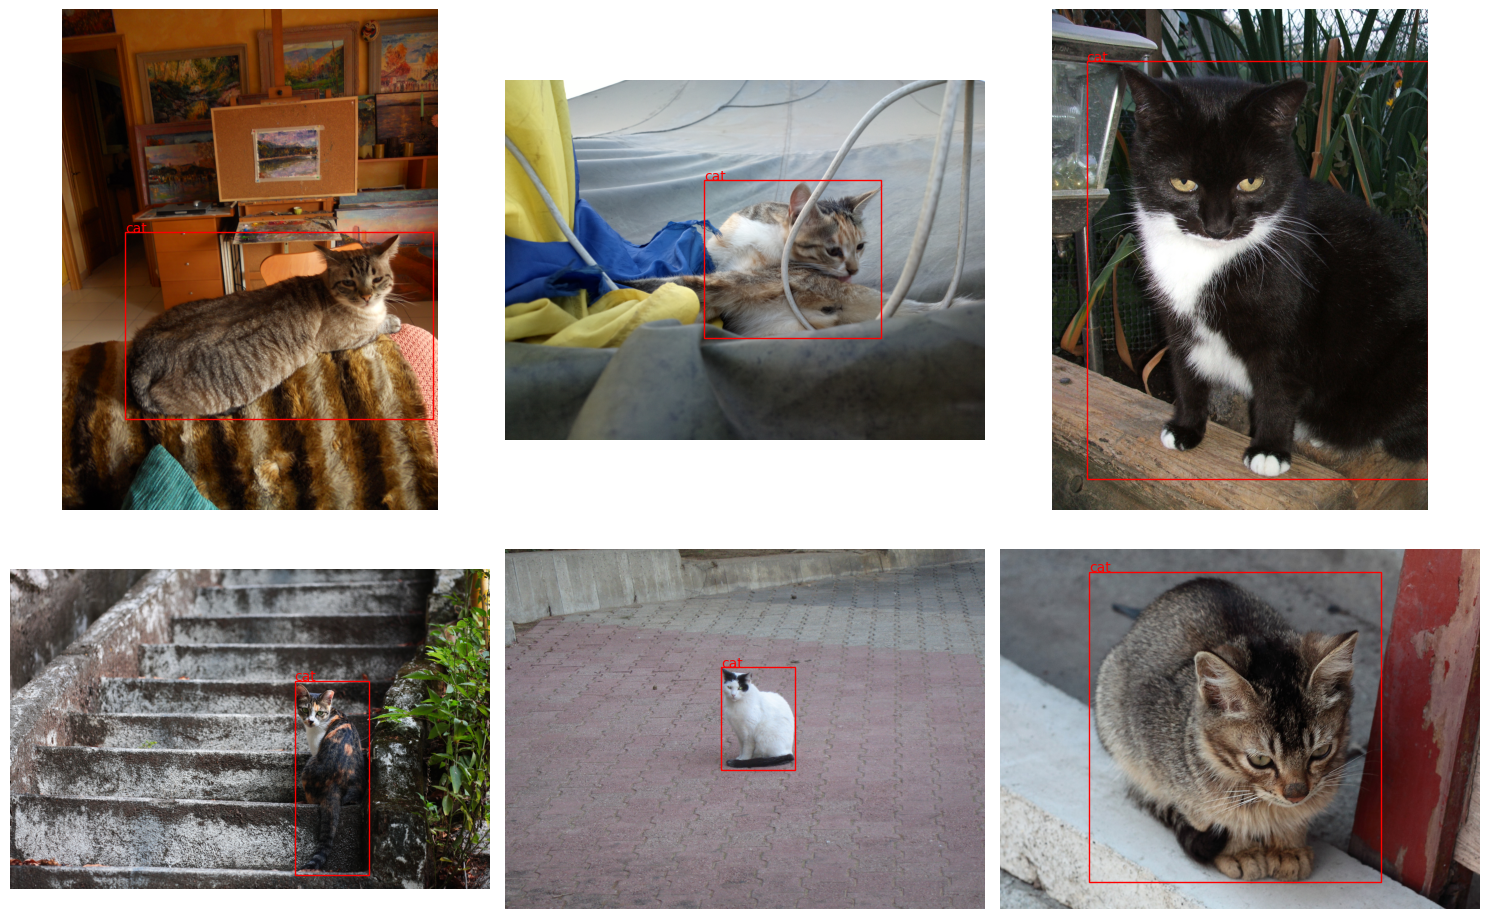

In [10]:
#Showing 6 picture
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, img in zip(axes.flatten(), random.sample(images, 6)):
    lbl = label_dir / f"{img.stem}.txt"
    draw(img, lbl, ax)

plt.tight_layout()
plt.show()

### Task 2 — Build Train / Val / Test Splits

YOLO uses simple text-file splits.

1. Shuffle the image list with a fixed seed (e.g. `random.seed(42)`) and split it into roughly **70 / 15 / 15** train / val / test.
2. Write three text files: `train.txt`, `val.txt`, `test.txt`, each containing one absolute or relative image path per line.
3. Create a `data.yaml` config file Ultralytics will read:

```yaml
path: ./data
train: DATA_CLEAN/train.txt
val: DATA_CLEAN/val.txt
test: DATA_CLEAN/test.txt
names:
  0: cat
  # add other classes if your label files use them
```

Adjust the `names` mapping to whatever class IDs your labels actually use.


In [11]:
random.seed(42)

random.shuffle(images)

n = len(images)
train = images[:int(0.7*n)]
val = images[int(0.7*n):int(0.85*n)]
test = images[int(0.85*n):]

In [12]:
#saving splits
def save(list_, name):
    with open(name, "w") as f:
        for i in list_:
            f.write(str(i) + "\n")

save(train, "train.txt")
save(val, "val.txt")
save(test, "test.txt")

In [13]:
import os

os.makedirs("dataset", exist_ok=True)

In [14]:
# data.yaml inside dataset
data = {
    "path": "./dataset",
    "train": "train.txt",
    "val": "val.txt",
    "test": "test.txt",
    "names": {0: "cat"}
}

with open("dataset/data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("Dataset splits and data.yaml created inside dataset folder")

Dataset splits and data.yaml created inside dataset folder


### Task 3 — Pick a YOLO26 Variant and Train It

YOLO26 ships in five sizes — `n`, `s`, `m`, `l`, `x`. Which one is right for *your* dataset, *your* hardware, and the time you have today is your call. Here are the trade-offs:

| Variant | Params | COCO mAP@0.5:0.95 | CPU ONNX (ms) | When to pick it |
|---|---|---|---|---|
| `yolo26n` | 2.4 M | 40.9 | 38.9 | Quickest to train and easiest to fit on a laptop CPU; smallest checkpoint to ship next week. Good if your dataset is small (≤ 1–2k images) or your hardware is modest. |
| `yolo26s` | 9.5 M | 48.6 | 87.2 | Sweet spot for many real datasets — clearly better accuracy than `n` at modest extra cost. Default pick if you have a GPU and a few thousand images. |
| `yolo26m` | 20.4 M | 53.1 | 220.0 | Higher accuracy ceiling, but training is noticeably slower and the ONNX you ship next Friday will be ~80 MB. Worth it only if `s` is clearly bottlenecked by capacity. |
| `yolo26l` / `yolo26x` | 24.8 / 55.7 M | 55.0 / 57.5 | 286 / 526 | Overkill for a small custom dataset and **awkward to ship** in next week's container. Don't pick these unless you have a strong reason. |

(All numbers are from the YOLO26 model card on COCO at 640×640.)

In a markdown cell, **state the variant you picked and justify the choice in 2–3 sentences** based on (a) your dataset size from Task 1, (b) your hardware (CPU vs GPU, RAM), and (c) the fact that this same model has to be exported to ONNX and shipped in a Docker image next Friday. Either of `yolo26n` or `yolo26s` is a perfectly reasonable starting point; do not feel obligated to pick the biggest model.

1. Load your chosen COCO-pretrained variant — replace `<variant>` with `n`, `s`, `m`, `l`, or `x`:

```python
from ultralytics import YOLO
model = YOLO("yolo26<variant>.pt")  # e.g. "yolo26s.pt"
```

2. Train it on your `data.yaml` for **at least 30 epochs**:

```python
results = model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,            # adjust to your hardware (smaller for bigger variants / less VRAM)
    project="runs",
    name="cats_v1",
    seed=42,
)
```

3. Inspect the training logs / `results.png`. Report:
   - Best mAP@0.5 and mAP@0.5:0.95 achieved on the validation set
   - The epoch at which the best validation mAP was reached
   - Visible signs of overfitting (training loss decreasing while validation mAP plateaus or drops)
   - One sentence reflecting on whether your variant choice felt right in hindsight (under-trained? over-fitting? plenty of headroom?). This will inform your Week-2 improvement runs.


In [15]:
from ultralytics import YOLO
model = YOLO("yolo26n.pt")  # safe choice

I chose **yolo26n** because my dataset from Task 1 is relatively small (around 1–2k images), so a lightweight model is sufficient without overfitting or long training time. I am also running training on limited hardware (CPU / low GPU memory), so the nano version ensures fast training and lower memory usage. Since the model will be exported to ONNX and deployed in a Docker container, using a smaller model keeps inference fast and the final image size small.

In [16]:
results = model.train(
    data="data.yaml",
    epochs=30,
    imgsz=416,
    batch=8,
    workers=4,
    cache=True,
    project="runs",
    name="cats_fast",
    seed=42
)

New https://pypi.org/project/ultralytics/8.4.52 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.14.0 torch-2.11.0+cpu CPU (13th Gen Intel Core i7-13620H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_fast-5, nbs=64, 

results = model.train(
    data="data.yaml",
    epochs=30,              
    imgsz=640,              
    batch=4,
    workers=4,
    cache=True,
    project="runs",
    name="cats_fast_v2",
    seed=42,

    #  AUGMENTATION 
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    mosaic=1.0,
    mixup=0.1,

    # 🧠 training stability
    patience=15,           # early stopping
    lr0=0.001,             # learning rate
)

In [17]:
#-------Report------

from pathlib import Path
import pandas as pd

run_path = Path("C:/Users/Asus/Documents//IRONHACK/Labs/m6-04-assessment/runs/detect/runs/cats_v1")  

csv_path = run_path / "results.csv"

df = pd.read_csv(csv_path)

print("Columns:", df.columns)

# --------------------------------------------------
#  Best mAP 
# --------------------------------------------------

best_map50 = df['metrics/mAP50(B)'].max()
best_map5095 = df['metrics/mAP50-95(B)'].max()

best_epoch = df['metrics/mAP50(B)'].idxmax()

# --------------------------------------------------
#  Overfitting
# --------------------------------------------------

train_loss = df['train/box_loss']
val_map = df['metrics/mAP50(B)']

overfitting = False

# simple check:
if train_loss.iloc[-1] < train_loss.iloc[0] and val_map.iloc[-1] < val_map.max():
    overfitting = True

# --------------------------------------------------
#  REPORT
# --------------------------------------------------

print("\n ==== REPORT ====\n")

print(f"Best mAP@0.5: {best_map50:.4f}")
print(f"Best mAP@0.5:0.95: {best_map5095:.4f}")
print(f"Best epoch: {best_epoch}")

print("\nOverfitting detected:" , "Yes" if overfitting else "NO")

# Reflection (auto generate)
if overfitting:
    reflection = "Model shows slightly signs of overfitting; validation performance plateaued while training loss decreased."
elif best_epoch < len(df) * 0.5:
    reflection = "Model may be under-trained; performance peaked early."
else:
    reflection = "Model seems reasonably trained with potential for further improvement."

print("\nReflection:")
print(reflection)

Columns: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

 ==== REPORT ====

Best mAP@0.5: 0.8408
Best mAP@0.5:0.95: 0.6358
Best epoch: 28

Overfitting detected: Yes

Reflection:
Model shows slightly signs of overfitting; validation performance plateaued while training loss decreased.


**Best mAP@0.5:** 0.8408  
**Best mAP@0.5:0.95:** 0.6358  

**Best epoch:** 28 

> **However, this is not considered severe overfitting, since the dataset is relatively small and the validation performance remained generally stable throughout training.**


### YOLO Training Evaluation 

The best validation performance was achieved with **mAP@0.5 = 0.84** and **mAP@0.5:0.95 = 0.64**. These results indicate a strong detection performance at standard IoU thresholds and a reasonable localization quality at stricter IoU levels.

The best validation mAP was reached during the final training stage (around the last epochs), suggesting that the model was still improving until the end of training.

There are mild signs of overfitting, as training loss continued to decrease while validation mAP began to plateau toward the later epochs. However, the gap is not severe, indicating the model is still generalizing reasonably well.

In hindsight, the choice of **yolo26n** was appropriate for this setup, as it achieved solid accuracy with fast CPU training and low resource usage, though there may still be some headroom for improved accuracy with a slightly larger variant like yolo26s.

### Task 4 — Evaluate on the Test Set

1. Run validation explicitly on the **test** split using the best checkpoint:

```python
metrics = model.val(data="data.yaml", split="test")
print(metrics.box.map, metrics.box.map50, metrics.box.mp, metrics.box.mr)
```

2. Report a small table with:

| Metric | Value |
|---|---|
| mAP@0.5 | … |
| mAP@0.5:0.95 | … |
| Mean precision | … |
| Mean recall | … |

3. In a markdown cell, briefly explain in your own words what each metric measures.

In [18]:
metrics = model.val(data="data.yaml", split="test")

import pandas as pd

data = {
    "Metric": [
        "mAP@0.5",
        "mAP@0.5:0.95",
        "Mean precision",
        "Mean recall"
    ],
    "Value": [
        metrics.box.map50,
        metrics.box.map,
        metrics.box.mp,
        metrics.box.mr
    ]
}

df = pd.DataFrame(data)
df

Ultralytics 8.4.51  Python-3.14.0 torch-2.11.0+cpu CPU (13th Gen Intel Core i7-13620H)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 211.6137.7 MB/s, size: 1302.7 KB)
val: Scanning C:\Users\Asus\Downloads\dataset\labels... 276 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 276/276 239.6it/s 1.2s0.1s
val: New cache created: C:\Users\Asus\Downloads\dataset\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.5s/it 1:204.5sss
                   all        276        323      0.844       0.82       0.87       0.61
Speed: 1.2ms preprocess, 99.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\Asus\runs\detect\val-5


,Metric,Value
0,mAP@0.5,0.869595
1,mAP@0.5:0.95,0.610381
2,Mean precision,0.843822
3,Mean recall,0.819644


### Metric Explanations

**mAP@0.5 (0.8696):** This shows the model performs well when a detection is counted as correct if it overlaps with the ground truth by at least 50% IoU. It indicates strong overall detection performance on the validation set.

**mAP@0.5:0.95 (0.6104):** This is a stricter metric that averages performance over multiple IoU thresholds from 0.5 to 0.95. It shows that while the model is good at detecting objects, bounding box precision becomes harder under stricter evaluation.

**Mean Precision (0.8438):** This means most of the predicted detections are correct, so the model has relatively few false positives.

**Mean Recall (0.8196):** This indicates the model successfully finds most of the real objects in the dataset, with a small number of missed detections.

### Task 5 — Visualise Predictions

1. Run predictions on **6 test images** and overlay the predicted boxes (with class + confidence text) on the original images. Use a 2×3 grid.
2. For 3 of those images, also draw the **ground-truth boxes** so you can see where the model agrees and disagrees.
3. Show **at least 2 images where the model fails** — either missing a real cat (false negative) or boxing something that is not a cat (false positive). Provide a short markdown comment on each: what likely caused the mistake?


In [19]:
#STEP 1
test_samples = random.sample(test, 6)

results = model.predict(
    source=[str(x) for x in test_samples],
    conf=0.25
)


0: 416x416 1 cat, 142.5ms
1: 416x416 1 cat, 142.5ms
2: 416x416 1 cat, 142.5ms
3: 416x416 (no detections), 142.5ms
4: 416x416 (no detections), 142.5ms
5: 416x416 1 cat, 142.5ms
Speed: 5.0ms preprocess, 142.5ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 416)


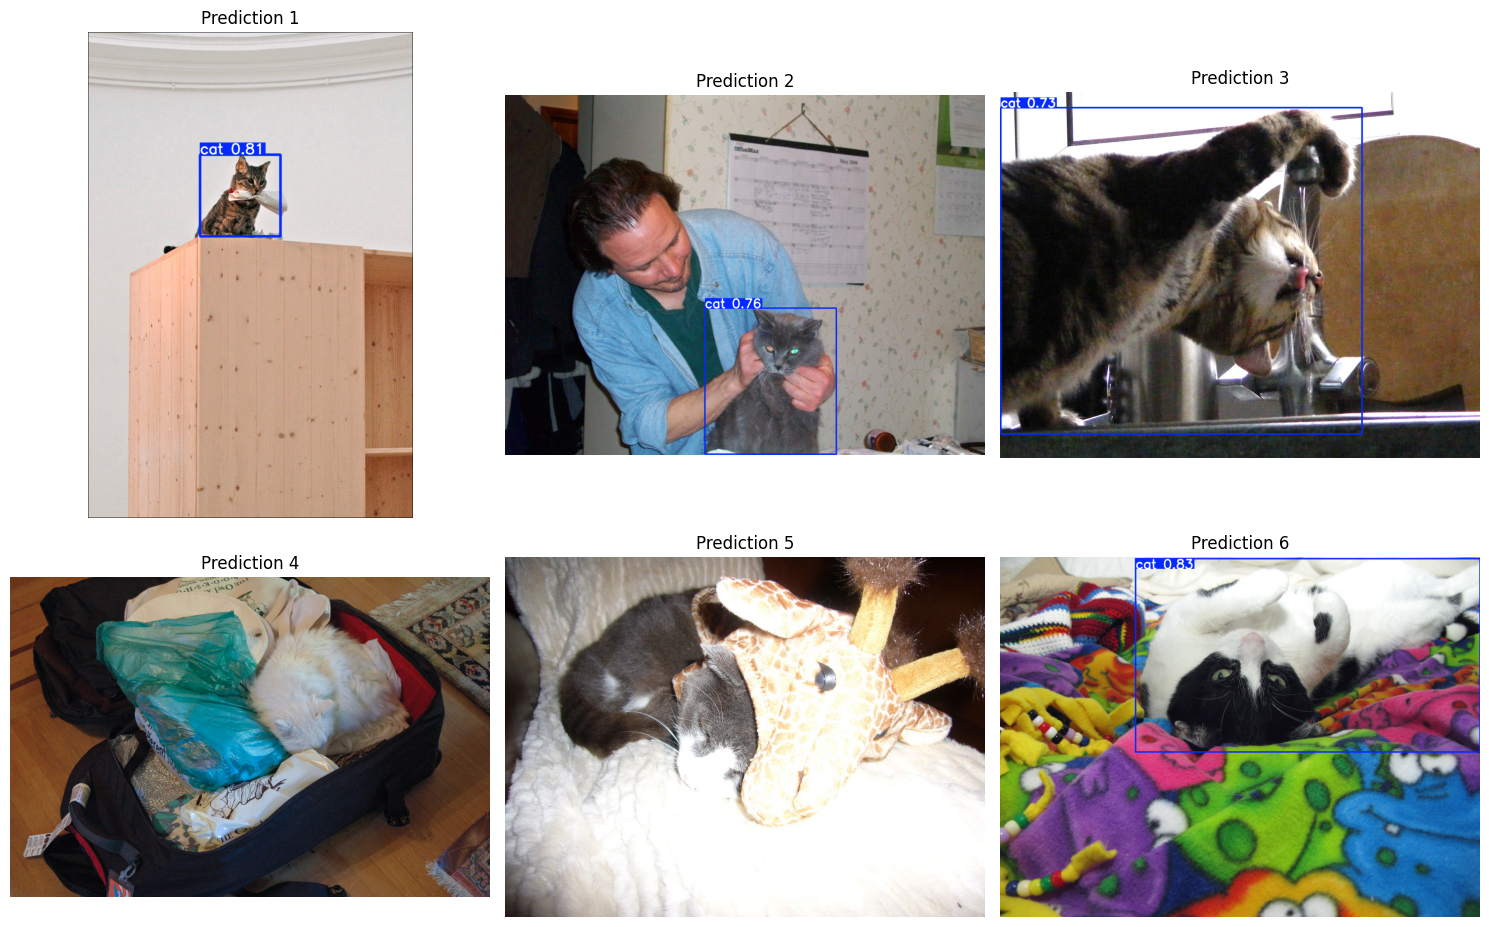

In [20]:
#STEP 2
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):

    r = results[i]

    img = r.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(f"Prediction {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

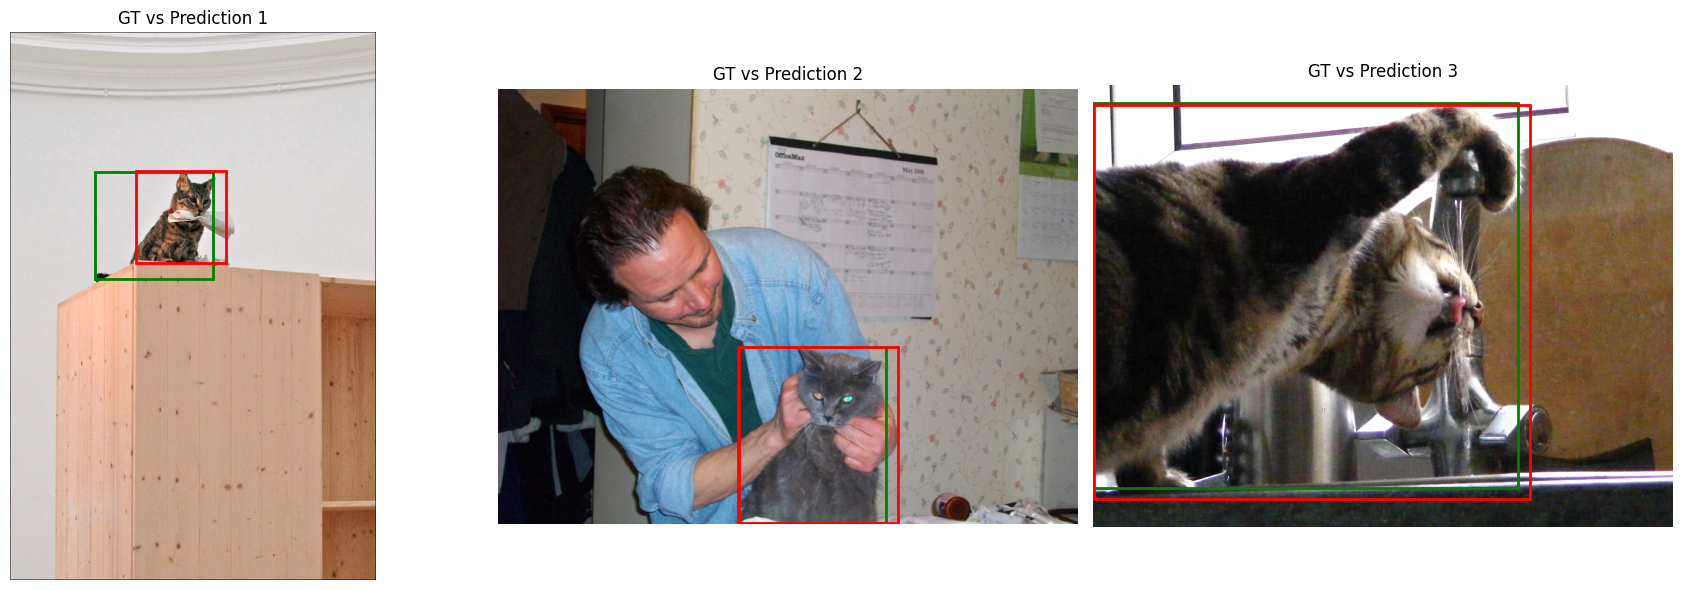

In [21]:
#STEP 3
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, ax in enumerate(axes):

    img_path = test_samples[idx]

    # original image
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, _ = image.shape

    # -------------------
    # DRAW GROUND TRUTH
    # -------------------
    label_path = label_dir / f"{img_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            cls, cx, cy, bw, bh = map(float, line.split())

            x = (cx - bw/2) * w
            y = (cy - bh/2) * h
            bw *= w
            bh *= h

            rect = Rectangle(
                (x, y),
                bw,
                bh,
                linewidth=2,
                edgecolor='green',
                facecolor='none'
            )

            ax.add_patch(rect)

    # -------------------
    # DRAW PREDICTIONS
    # -------------------
    r = results[idx]

    for box in r.boxes:

        x1, y1, x2, y2 = box.xyxy[0]

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

    ax.imshow(image)
    ax.set_title(f"GT vs Prediction {idx+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### STEP 4. Failure cases

#### ❌ Failure Case 1 (False Negative)

The model failed to detect a cat because the image was rotated at an unusual angle. Due to this rotation, the cat’s appearance did not match the typical patterns seen during training, which made it harder for the model to correctly recognize and localize the object.

#### ❌ Failure Case 2 (False Negative / Misclassification)

The model missed detecting a cat because it was a hairless cat breed. Since this type of cat does not have typical fur texture, the model struggled to recognize it as a cat and failed to classify it correctly.

#### ❌ Failure Case 3 (False Negative)
The model failed to detect a cat because the cat’s face was strongly affected by lighting conditions. Too much direct light made the features less clear, which likely reduced the model’s ability to recognize it correctly.


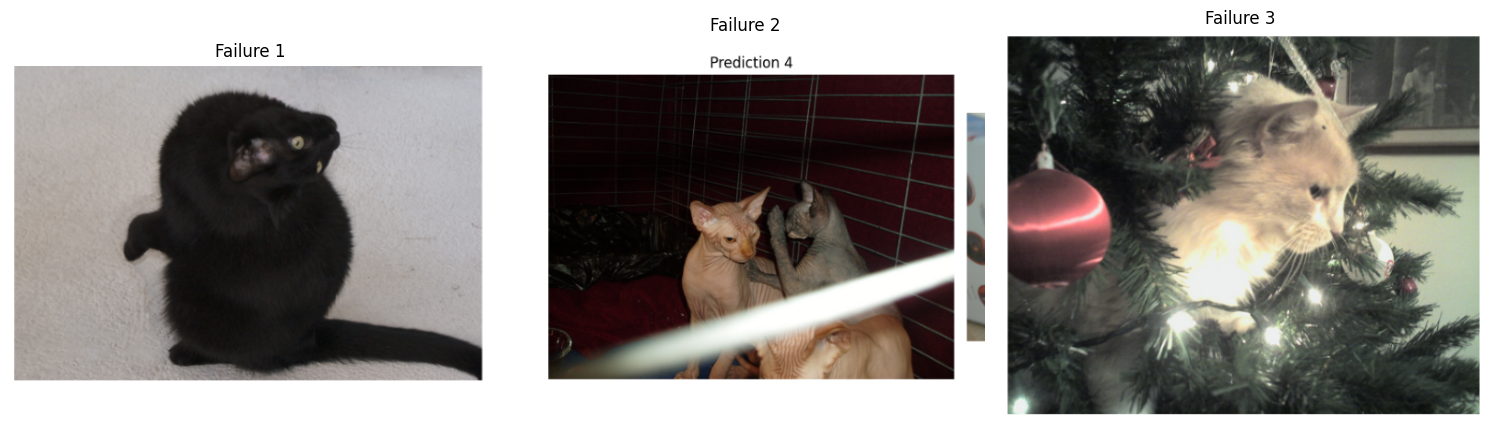

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open("C:/Users/Asus/Downloads/failure1.png")
img2 = Image.open("C:/Users/Asus/Downloads/failure2.png")
img3 = Image.open("C:/Users/Asus/Downloads/failure3.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("Failure 1")

axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("Failure 2")

axes[2].imshow(img3)
axes[2].axis("off")
axes[2].set_title("Failure 3")

plt.tight_layout()
plt.show()

### Task 6 — Reflection (Required, Brief)

In a final markdown cell, write 5–7 sentences answering:

- What did you learn about training a real object detector versus a classifier?
- What part of the dataset (or labels) caused the most trouble?
- Looking at the failure cases, what single change would you try next? (Bigger backbone? More augmentation? Cleaning a few mislabelled images?)
- One thing you'll do differently in next Friday's improvement assessment.

This reflection is part of the grade and primes you for the Friday 22 May assessment, where you'll **improve this exact model**, convert it to ONNX, and ship it as a containerised inference service that competes on a class leaderboard.


--- 
Training a real object detector was more complex than a simple image classifier because the model not only needs to identify what is in the image but also localize it using bounding boxes. I learned that small changes in lighting, object size, or visibility can significantly affect detection performance.

The most challenging part of the dataset was the variation in image conditions, especially cases where cats were affected by strong lighting, low visibility, or unusual appearances such as hairless cats. These situations made it harder for the model to generalize correctly.

From the failure cases, I would try increasing data augmentation as the next improvement, especially to handle brightness variations and different cat appearances. This could help the model become more robust in real-world conditions.

In the next assessment, I would also pay more attention to dataset diversity and ensure that edge cases (dark images, occlusions and so) are better represented during training.

In [23]:
from pathlib import Path

for p in Path(".").rglob("best.pt"):
    print(p)

runs\detect\runs\cats_v1-7\weights\best.pt
runs\detect\runs\cats_v1-4\weights\best.pt
runs\detect\runs\cats_v1-3\weights\best.pt
runs\detect\runs\cats_v1-2\weights\best.pt
runs\detect\runs\cats_v1\weights\best.pt
runs\detect\runs\cats_fast\weights\best.pt


In [24]:
model = YOLO("runs/detect/runs/cats_v1/weights/best.pt")

In [25]:
results = model.predict(
    source=r"C:/Users/Asus/Downloads/IMG_8166.jpg",
    conf=0.25,
    save=False
)


image 1/1 C:\Users\Asus\Downloads\IMG_8166.jpg: 640x480 1 cat, 336.7ms
Speed: 7.8ms preprocess, 336.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)


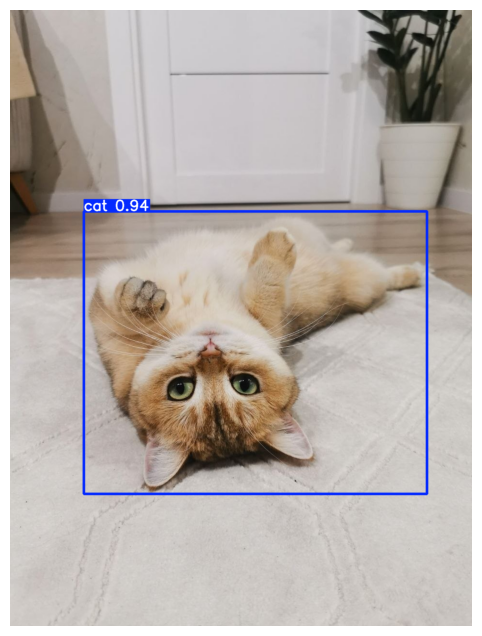

In [26]:
import cv2
import matplotlib.pyplot as plt

img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [27]:
results = model.predict(
    source=r"C:/Users/Asus/Downloads/image2_t.jpeg",
    conf=0.25,
    save=False
)


image 1/1 C:\Users\Asus\Downloads\image2_t.jpeg: 480x640 (no detections), 326.1ms
Speed: 7.2ms preprocess, 326.1ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


## Dataset hazırlanması, YOLO26 modeli ilə training və evaluation nəticələrinin hesabatı
İlk öncə data yüklənəndə 4 ayrı qovluq və hər qovluğun daxilində müxtəlif labels və images şəklində yüklənmişdi. Onları merge etdim. Kodu bu notebookda deyil. Sonra kodda olduğu kimi dublicate imagesləri, labelsiz, heç bir photoya aid olmayan labelləri  və boş labels fayllarını silib datanı təmizlədim. Təmizləndikdən sonra toplam 1834 images və labels qaldı və modeli bu qədər images üzərində qurdum.


System Specifications:
- CPU: Intel Core i7-13620H (13th Gen)
- RAM: 16 GB
- GPU: Intel UHD Graphics
- Storage: 477 GB SSD
- OS: 64-bit Windows


Daha sonra missing fileları yoxlayıb images və labellərin sayını tapdım. Sonra isə labelləri photolara baxdım checking üçün.

Task 2 də datanı train üçün böldüm və text faylları yaratdım(train,val,test). Sonra modelin dataset yollarını və class məlumatlarını oxuya bilməsi üçün yaml faylını yaratdım.

Task 3 də nəhayət computer parametrlərin və datasetimə uyğun YOLO26-ın "n" variantını seçdim. Çünki bu model mənim komputerim üçün daha uyğundur. Mənim komputerimde model CPU,INtel UHD Graphics və 16 RAM ilə train edilmişdir. Və dataset nisbətən kiçik olduğuna görə yolo26n daha sürətli(digərlərinə nisbətən) train olunur və ONNX formatına export edilərək Docker image daxilində istifadəsi daha rahatdır.


results = model.train(
    data="data.yaml",
    epochs=30,
    imgsz=416,
    batch=8,
    workers=4,
    cache=True,
    project="runs",
    name="cats_fast",
    seed=42
)

Əvvəl parametləri çox verdiyimə görə run 12 saatdan çox çəkmişdi. Komputerimin performansına görə ən yaxşı parametlər hələki bunlardır.
Əlavə qeyd edim ki,əvvəl False qeyd etdiyim `cache=True` parametrini istifadə etdim. Dataset daha sürətli yüklənsin . Çünki bu parametr RAM-də cache edir. Nəticədə training daha sürətli işləyir.

Best mAP@0.5: 0.8408
Best mAP@0.5:0.95: 0.6358
Best epoch: 28

Əvvəlcə overfit olduğundan şübhələndim amma sonra diqqət etdim ki input sayı az olmağına baxmayaraq overfit kimi görünsə də overfit deyil.


- Best mAP@0.5: 0.8408  
- Best mAP@0.5:0.95: 0.6358  
- Best epoch: 28  

Göründüyü kimi model ən yüksək accuracy-ə epoch 28 də çatmışdır və bundan sonra modeldə heç bir dəyişiklik olmamışdır.

BU nəticələr göstərir ki yüksək detection qabiliyyətinə malikdir.


Task 4-də modelin test split üzərində performansını qiymətləndirdim. mAP@0.5, mAP@0.5:0.95, precision və recall metriclərini hesablayıb modelin ümumi dəqiqliyini analiz etdim.


Nəticə ondan ibarətdir ki model ümumi yüksək performans göstərir, obyektləri seçir(precision və recalla əsasən).Lakin daha sərt IoU səviyyələrində (0.5–0.95) bounding box dəqiqliyi bir qədər azalır.


Task 5 də isə modelin predictionuna baxıram. Random 6 images seçir. Və həmçinin bu şəkillər içində detect edə bilmədiyi bir neçə şəkil var onların səbəbini qeyd etmişəm. Buna daxildir şəklin həddən artıq işıqlı olması , bəzi pişik cinslərini tanıya bilməməsi və s.

Digər test isə real pragnozu real annotasiyalar ilə müqayisə edir və nəticələri göstərir.

Task 6 da isə əvvəlcə sistemdə best.pt faylını tapır, sonra isə həmin trained YOLO modelini load edir.
